In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re 
import glob
from matplotlib.gridspec import GridSpec
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle
import matplotlib.ticker as ticker

In [2]:
# Read in data
df = pd.read_csv('../data/clustered_dr_all_cells_2022_09_15_patient_updated.csv', index_col=0)
df.head()

,209Bi_CD45,Center,164Dy,166Er_CD34,Event_length,157Gd,113In_CD45,191Ir_DNA1,193Ir_DNA2,104Pd_CD45,...,171Yb_Granzyme_B_asinh_coarseAlign_fineAlign,172Yb_CD38_asinh_coarseAlign_fineAlign,173Yb_CD14_asinh_coarseAlign_fineAlign,174Yb_HLA-DR_asinh_coarseAlign_fineAlign,176Yb_CD56_asinh_coarseAlign_fineAlign,Alignment_MC_fineAlign,FlowSOM_cluster,FlowSOM_metacluster,UMAP_X,UMAP_Y
1,0.00000,633.973,0.0,0.00000,15,0.0,0.0,249.076,400.114,0.0,...,2.951135,0.961040,0.047869,0.053259,0.044064,5,179,39,0.075119,9.367344
2,0.00000,855.374,0.0,0.00000,17,0.0,0.0,218.016,455.480,0.0,...,0.113675,1.902335,1.078308,2.566125,0.085914,1,35,2,-0.657520,-6.955027
3,2.47164,625.283,0.0,0.00000,15,0.0,0.0,223.581,583.897,0.0,...,5.450052,1.786209,0.009813,0.905944,3.293293,4,186,33,-10.401136,3.650752
4,0.00000,795.305,0.0,0.00000,17,0.0,0.0,189.046,480.253,0.0,...,5.067924,1.552994,0.014530,0.073580,1.197077,7,192,39,-0.358508,9.502626
5,0.00000,0.000,0.0,1.32702,16,0.0,0.0,118.551,241.897,0.0,...,0.709685,3.955264,0.255739,0.540499,0.085914,1,9,3,0.421227,-3.556041


In [3]:
# Delete spare progression sample (there was a second later measurement which was associated with progression)
# Delete sample 61290 006 as the patient went off trial due to participant preference
print(df.shape)
df = df.loc[df['FileName'] != 'P02_SPD_T_Cell_Panel',:]
df = df.loc[~df['FileName'].str.contains('P26'),:]
df['FileName'] = df['FileName'].str.replace('P02_SPD_2_T_Cell_Panel', 'P02_SPD_T_Cell_Panel')
df['Timepoint'] = df['Timepoint'].str.replace('SPD_2', 'SPD')
df['Patient_ID'] = df['Patient_ID'].str.replace('61250_004_2', '61250_004')

# Delete the following samples as they have only a single measurement
df = df.loc[~df['FileName'].str.contains('P27'),:]
df = df.loc[~df['FileName'].str.contains('P15'),:]
print(df.shape)

(295000, 68)
(282500, 68)


In [4]:
# Read in clustering results
cell_type = pd.read_csv('../data/t_cell_clsuters_2025_05_20.csv')
cell_type_dict = dict(zip(cell_type['cluster'], cell_type['cell_type']))
cell_type_dict

{4: 'B cell',
 23: 'Cytokine NK Cell',
 24: 'Cytotoxic NK Cell',
 28: 'Cytotoxic NK Cell',
 33: 'Cytotoxic NK Cell',
 34: 'Cytotoxic NK Cell',
 35: 'Cytotoxic NK Cell',
 14: 'Plasma cell',
 10: 'CD4_T_cell',
 13: 'Treg',
 20: 'Treg',
 39: 'Cytotoxic_CD4',
 40: 'Cytotoxic_CD4',
 5: 'CD56_Myeloid',
 6: 'CD56_Myeloid',
 12: 'CD8_T_cell',
 27: 'CD8_T_cell',
 30: 'Cytotoxic CD56+ CD8 T cell',
 31: 'CD8_T_cell',
 32: 'Cytotoxic CD8',
 36: 'Cytotoxic CD8',
 38: 'Cytotoxic CD8',
 1: 'Monocytes',
 2: 'Monocytes',
 15: 'Monocytes',
 3: 'HSPCs',
 8: 'Immature myeloid',
 7: 'Neutrophils',
 9: 'Neutrophils',
 11: 'Neutrophils',
 16: 'Neutrophils',
 17: 'Neutrophils',
 21: 'Cytokine NK Cell',
 22: 'Cytotoxic NK Cell',
 29: 'Cytotoxic NK Cell',
 37: 'Cytotoxic NK Cell',
 18: 'CD56+ CD8 T cell',
 19: 'Cytotoxic CD8',
 25: 'Cytotoxic CD8',
 26: 'Cytotoxic CD56+ CD8 T cell'}

In [5]:
# Manually identify each clustering result
df['cell_type'] = df['FlowSOM_metacluster'].map(cell_type_dict)
df['cell_type'] = df['cell_type'].str.replace('_',  ' ')
df['cell_type'] = df['cell_type'].str.replace(' pos',  '+')
df.head()

,209Bi_CD45,Center,164Dy,166Er_CD34,Event_length,157Gd,113In_CD45,191Ir_DNA1,193Ir_DNA2,104Pd_CD45,...,172Yb_CD38_asinh_coarseAlign_fineAlign,173Yb_CD14_asinh_coarseAlign_fineAlign,174Yb_HLA-DR_asinh_coarseAlign_fineAlign,176Yb_CD56_asinh_coarseAlign_fineAlign,Alignment_MC_fineAlign,FlowSOM_cluster,FlowSOM_metacluster,UMAP_X,UMAP_Y,cell_type
1,0.00000,633.973,0.0,0.00000,15,0.0,0.0,249.076,400.114,0.0,...,0.961040,0.047869,0.053259,0.044064,5,179,39,0.075119,9.367344,Cytotoxic CD4
2,0.00000,855.374,0.0,0.00000,17,0.0,0.0,218.016,455.480,0.0,...,1.902335,1.078308,2.566125,0.085914,1,35,2,-0.657520,-6.955027,Monocytes
3,2.47164,625.283,0.0,0.00000,15,0.0,0.0,223.581,583.897,0.0,...,1.786209,0.009813,0.905944,3.293293,4,186,33,-10.401136,3.650752,Cytotoxic NK Cell
4,0.00000,795.305,0.0,0.00000,17,0.0,0.0,189.046,480.253,0.0,...,1.552994,0.014530,0.073580,1.197077,7,192,39,-0.358508,9.502626,Cytotoxic CD4
5,0.00000,0.000,0.0,1.32702,16,0.0,0.0,118.551,241.897,0.0,...,3.955264,0.255739,0.540499,0.085914,1,9,3,0.421227,-3.556041,HSPCs


In [6]:
# Delete the spare columns called '7 month response' and '12 month response'. I will then add
# some clinical information which Julie recently gave me
print(df.shape)
df = df.drop(['7_month_response', '12_month_response'], axis = 1)
print(df.shape)


(282500, 69)
(282500, 67)


In [7]:
df.columns

Index(['209Bi_CD45', 'Center', '164Dy', '166Er_CD34', 'Event_length', '157Gd',
       '113In_CD45', '191Ir_DNA1', '193Ir_DNA2', '104Pd_CD45', '106Pd_CD45',
       '108Pd_CD45', '110Pd_CD45', '194Pt_Cisplatin1', '195Pt_Cisplatin2',
       '154Sm_CD45', '159Tb', '89Y_CD45', 'Time', 'FileName', 'FileNo', 'V1',
       'Date', 'Patient_ID', 'Timepoint', 'Batch_Control', 'Reference',
       'Healthy', 'Disease', 'Batch',
       '161Dy_CD335_Nkp46_asinh_coarseAlign_fineAlign',
       '162Dy_FoxP3_asinh_coarseAlign_fineAlign',
       '163Dy_CD183_CXCR3_asinh_coarseAlign_fineAlign',
       '167Er_CD33_asinh_coarseAlign_fineAlign',
       '168Er_Ki67_asinh_coarseAlign_fineAlign',
       '170Er_CD3_asinh_coarseAlign_fineAlign',
       '151Eu_CD39_asinh_coarseAlign_fineAlign',
       '153Eu_CD314_asinh_coarseAlign_fineAlign',
       '156Gd_CD279_PD1_asinh_coarseAlign_fineAlign',
       '158Gd_CD194_CCR4_asinh_coarseAlign_fineAlign',
       '160Gd_CD197_CCR7_asinh_coarseAlign_fineAlign',
       '16

In [8]:
# 

df['Timepoint'] = df['Timepoint'].str.replace('Healthy_Control', 'Control')

outcomes = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx')
diagnosis_dict = dict(zip(outcomes['PID'], outcomes['Diagnosis']))
out_6_dict = dict(zip(outcomes['PID'], outcomes['Outcome_C6_revised_Vid']))
out_12_dict = dict(zip(outcomes['PID'], outcomes['Outcome_C12_CC486']))

df['diagnosis'] = df['Patient_ID'].map(diagnosis_dict)
df['outcome_6'] = df['Patient_ID'].map(out_6_dict)
df['outcome_12'] = df['Patient_ID'].map(out_12_dict)

In [9]:
pid_timepoint = [f"{x}_{y.replace('_', '')}" if 'P' in x else x for x, y in zip(df['Patient_ID'], df['Timepoint'])]

df['pid_timepoint'] = pid_timepoint
df['pid_timepoint'] = df['pid_timepoint'].astype(str)
df['pid_timepoint'].unique()

array(['P08_C1D8', 'P08_C7D1', 'P08_C7D22', 'P08_SPD', 'P24_C1D1',
       'P24_C1D8', 'P24_C7D1', 'P19_C1D1', 'P19_C1D8', 'P19_C7D1',
       'P19_C7D22', 'P12_C1D1', 'P12_C1D8', 'P12_C12D29', 'P12_C7D22',
       'P04_C1D1', 'P04_C1D8', 'P04_C12D29', 'P04_C7D22', 'P03_C1D1',
       'P03_C1D8', 'P03_C12D29', 'P03_C7D1', 'P03_C7D22', 'P38_C1D1',
       'P38_C1D8', 'P06_C12D29', 'P06_C7D1', 'P06_C7D22', 'P10_C1D1',
       'P10_C1D8', 'P10_C12D29', 'P10_C7D1', 'P10_C7D22', 'P16_C1D1',
       'P16_C1D8', 'P16_C7D1', 'P16_C7D22', 'P14_C1D1', 'P14_C1D8',
       'P14_C7D22', 'P14_SPD', 'P05_C1D1', 'P05_C1D8', 'P05_C12D29',
       'P02_C1D1', 'P02_C1D8', 'P02_C7D1', 'P02_C7D22', 'P02_SPD',
       'P01_C1D1', 'P01_C1D8', 'P01_C12D29', 'P01_C7D1', 'P01_C7D22',
       'P11_C1D1', 'P11_C1D8', 'P11_C12D29', 'P11_C7D1', 'P11_C7D22',
       'P28_C1D1', 'P28_C1D8', 'P07_C1D1', 'P07_C1D8', 'P07_C12D29',
       'P07_C7D1', 'P07_C7D22', 'P20_C1D8', 'P20_C7D22', 'P17_C1D1',
       'P17_C1D8', 'P17_C7D1', 'P

In [10]:
# Read in data from Julie. This dataframe contains the patient outcomes and time when a sample was collected 
timepoints = pd.read_excel('../data/MS_flow_outcome_dx_clean_updatedJan24_patient_updated.xlsx', index_col=0)
timepoints['PID_Timepoint'] = timepoints['PID'].astype(str) + '_' + timepoints['Cycle_day']
to_keep = ['Cycle_day', 'Day_since_C1D1', 'Day_since_scr', 'PID_Timepoint']
timepoints = timepoints.loc[:,timepoints.columns.isin(to_keep)]
timepoints.head()
cells = pd.merge(df, timepoints, left_on='pid_timepoint', right_on= 'PID_Timepoint', how = 'left')



In [11]:
# Use a dictionary to add a column called time which will be used for plotting
time = {'C1_D1': 1, 'C1_D8': 8, 'C7_D1': 168, 'C7_D22': 190, 'C12_D29': 336,
    'Progression': 275,  'Healthy': 0.4}
    
cells['time'] = cells['Timepoint'].map(time)
cells

,209Bi_CD45,Center,164Dy,166Er_CD34,Event_length,157Gd,113In_CD45,191Ir_DNA1,193Ir_DNA2,104Pd_CD45,...,cell_type,diagnosis,outcome_6,outcome_12,pid_timepoint,Cycle_day,Day_since_C1D1,Day_since_scr,PID_Timepoint,time
0,0.00000,633.973,0.0,0.00000,15,0.0000,0.00000,249.0760,400.114,0.000000,...,Cytotoxic CD4,MDS,non-responder_2,non-responder_2,P08_C1D8,C1D8,9.0,35.0,P08_C1D8,8.0
1,0.00000,855.374,0.0,0.00000,17,0.0000,0.00000,218.0160,455.480,0.000000,...,Monocytes,MDS,non-responder_2,non-responder_2,P08_C1D8,C1D8,9.0,35.0,P08_C1D8,8.0
2,2.47164,625.283,0.0,0.00000,15,0.0000,0.00000,223.5810,583.897,0.000000,...,Cytotoxic NK Cell,MDS,non-responder_2,non-responder_2,P08_C1D8,C1D8,9.0,35.0,P08_C1D8,8.0
3,0.00000,795.305,0.0,0.00000,17,0.0000,0.00000,189.0460,480.253,0.000000,...,Cytotoxic CD4,MDS,non-responder_2,non-responder_2,P08_C1D8,C1D8,9.0,35.0,P08_C1D8,8.0
4,0.00000,0.000,0.0,1.32702,16,0.0000,0.00000,118.5510,241.897,0.000000,...,HSPCs,MDS,non-responder_2,non-responder_2,P08_C1D8,C1D8,9.0,35.0,P08_C1D8,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
282495,302.09200,0.000,0.0,6.39191,14,0.0000,0.00000,92.5217,186.108,0.000000,...,B cell,NaN,NaN,NaN,Control_11,NaN,NaN,NaN,NaN,NaN
282496,292.54500,700.600,0.0,2.45148,18,0.0000,0.00000,138.9430,287.202,1.695570,...,CD56 Myeloid,NaN,NaN,NaN,Control_11,NaN,NaN,NaN,NaN,NaN
282497,411.17600,732.588,0.0,1.06027,16,0.0000,5.25005,106.9510,194.234,0.548167,...,CD4 T cell,NaN,NaN,NaN,Control_11,NaN,NaN,NaN,NaN,NaN
282498,21.89810,529.269,0.0,336.94700,13,0.0000,0.00000,168.9160,271.939,1.140420,...,HSPCs,NaN,NaN,NaN,Control_11,NaN,NaN,NaN,NaN,NaN


In [12]:
# Create a list so that I can delete the samples where I acquired a C7D22 but the patient dropped out for
# reasons unrelated to the disease or treatment note that these patients have an NA in the outcome_12 column
to_del = []
time_to_keep = ['non-responder_2', 'responder_1', 'Healthy']
for x, y, in zip(cells['pid_timepoint'], cells['outcome_12']):
    if x.__contains__('C7D22') & (y not in time_to_keep):
        to_del.append(x)

print(cells.shape)
cells1 = cells.loc[~cells['pid_timepoint'].isin(to_del), :]
print(cells1.shape)

del to_del

(282500, 76)
(277500, 76)


In [13]:
cells1['Healthy'].value_counts()

Healthy
Sample     230000
Healthy     47500
Name: count, dtype: int64

In [14]:
# Add a column called best response which details the best clinical response of each patient
# if a patient is called a responder at any timepont they are called a responder even if they eventually progress
best_response = []
for x, y, z in zip(cells1['outcome_6'], cells1['outcome_12'], cells1['Healthy']):
    if x == 'responder_1':
        best_response.append('responder_1')
    elif y == 'responder_1':
        best_response.append('responder_1')
    elif z == 'Healthy':
        best_response.append('Control')
    else:
        best_response.append('non-responder_2')

cells1['best_response'] = best_response
cells1.head()

/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_31916/3983847198.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cells1['best_response'] = best_response


,209Bi_CD45,Center,164Dy,166Er_CD34,Event_length,157Gd,113In_CD45,191Ir_DNA1,193Ir_DNA2,104Pd_CD45,...,diagnosis,outcome_6,outcome_12,pid_timepoint,Cycle_day,Day_since_C1D1,Day_since_scr,PID_Timepoint,time,best_response
0,0.00000,633.973,0.0,0.00000,15,0.0,0.0,249.076,400.114,0.0,...,MDS,non-responder_2,non-responder_2,P08_C1D8,C1D8,9.0,35.0,P08_C1D8,8.0,non-responder_2
1,0.00000,855.374,0.0,0.00000,17,0.0,0.0,218.016,455.480,0.0,...,MDS,non-responder_2,non-responder_2,P08_C1D8,C1D8,9.0,35.0,P08_C1D8,8.0,non-responder_2
2,2.47164,625.283,0.0,0.00000,15,0.0,0.0,223.581,583.897,0.0,...,MDS,non-responder_2,non-responder_2,P08_C1D8,C1D8,9.0,35.0,P08_C1D8,8.0,non-responder_2
3,0.00000,795.305,0.0,0.00000,17,0.0,0.0,189.046,480.253,0.0,...,MDS,non-responder_2,non-responder_2,P08_C1D8,C1D8,9.0,35.0,P08_C1D8,8.0,non-responder_2
4,0.00000,0.000,0.0,1.32702,16,0.0,0.0,118.551,241.897,0.0,...,MDS,non-responder_2,non-responder_2,P08_C1D8,C1D8,9.0,35.0,P08_C1D8,8.0,non-responder_2


In [15]:
cells1['best_response'].unique()

array(['non-responder_2', 'responder_1', 'Control'], dtype=object)

In [16]:
# Randomly reorder the rows
print(cells1.shape)
cells2 = cells1.sample(frac=1).reset_index(drop=True)
print(cells2.shape)

(277500, 77)
(277500, 77)


In [17]:
# Read in a sheet which details the cluster, color of each cluster and order of the plotting
order = pd.read_excel('../data/t_cell_panel_cluster_color_and_order.xlsx')
order = order.sort_values('Order')
order_dict = dict(zip(order['Cluster'], order['Order']))
color_dict = dict(zip(order['Cluster'], order['color']))

# Create a dictionary to specify the location of the numebrs to specify cluster identity in the UMAP plots
text_dict ={}
for label, x, y in zip(order['Order'], order['x_pos'], order['y_pos']):
    dict1 = {}
    dict1['xpos'] = x
    dict1['ypos'] = y
    text_dict[label] = dict1

In [18]:
cells2['cell_type'] = cells2['cell_type'].str.replace('Immature myeloid', 'Myeloid Progenitor')

/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_31916/3005464047.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


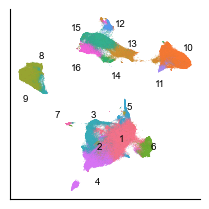

In [19]:
# Create a UMAP plot which details the cell types found in the dataset
plt.rcParams["font.family"] = "Arial"
plt.rcParams['svg.fonttype'] = 'none' # export font as editable text
plt.rcParams['pdf.fonttype'] = 'truetype' # export font as editable text

responder_color_dict = {'non-responder_2':'#fe9003', 'responder_1':'#115284', 'Healthy': 'grey'}
plt.rcParams.update({'mathtext.default':  'regular' })
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (2.2, 2.2), constrained_layout=True)


ax.scatter(x = cells2['UMAP_X'], y = cells2['UMAP_Y'], s = 0.1, c = cells2['cell_type'].map(color_dict), 
              linewidth = 0, rasterized=True)

for label, value in text_dict.items():
    ax.text(x=value['xpos'], y=value['ypos'], s=str(label), fontsize=7)
    
ax.legend([], frameon = False)  

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('')
ax.set_xticks([])
ax.set_yticks([])
ax.tick_params(axis = 'both', labelsize = 7, pad = 1, length = 1.5) 
        
plt.tight_layout()
# fig.savefig('../result/layout_version_8.png', pad_inches=0.1,  dpi = 600)
#fig.savefig('../result/layout_version_8.pdf', bbox_inches = 'tight', pad_inches=0.01,  dpi = 600)

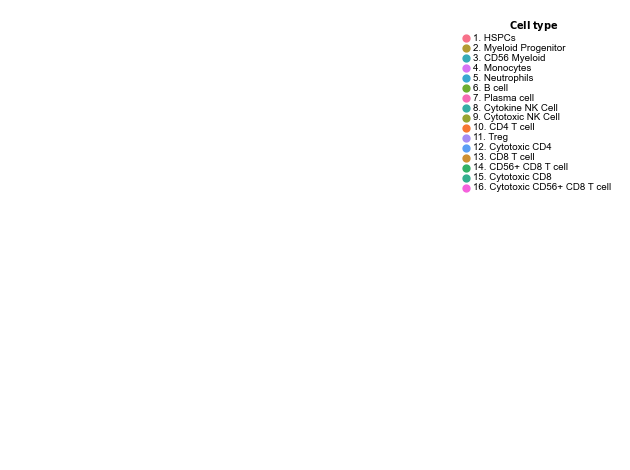

In [20]:
# Create a legend which details the names of the cell types found in the dataset
plt.rcParams["font.family"] = "Arial"
plt.rcParams['svg.fonttype'] = 'none' # export font as editable text
plt.rcParams['pdf.fonttype'] = 'truetype' # export font as editable text
handles3 = []
f3, a3 = plt.subplots()
for lab in order_dict.keys():
    line = a3.scatter([0],[0], label=lab, color=color_dict[lab], marker = 'o', s = 50, alpha = 1)
    handles3.append(line)    
plt.close(f3)
fig, ax = plt.subplots()
labels = color_dict.keys()
labels1 = []
for x, i in enumerate(labels):
    i = i.replace('_', ' ')
    i = i.replace(' pos ', '+ ')
    i = i.replace(' neg', '-')
    labels1.append(str(x +1) +'. ' + i)
ax.legend(handles = handles3, labels = labels1,
          title = "$\\bf{Cell}$" + ' ' + "$\\bf{type}$", bbox_to_anchor = (1.0, 1.0),
           ncol = 1, columnspacing = 0.8, handletextpad = -0.3, labelspacing = 0.1, fontsize = 7, frameon = False,
           title_fontsize = 7, markerscale = 0.7)

ax.axis('off')

plt.tight_layout()
#fig.savefig('../result/cell_type_legend_v1.pdf', bbox_inches = 'tight', pad_inches=0.01,  dpi = 1200)

In [21]:
# Create a dictionary to add text to certain clusters (not all in order)
order1 = order.loc[order['to_add_to_responder_non_responder_umap'] == 'Yes', :]
# Create a dictionary to specify the location of the numebrs to specify cluster identity in the UMAP plots
responder_text_dict ={}
for label, x, y in zip(order1['Order'], order1['x_pos'], order1['y_pos']):
    dict1 = {}
    dict1['xpos'] = x
    dict1['ypos'] = y
    responder_text_dict[label] = dict1
    

In [22]:
responder_text_dict


{2: {'xpos': -1.75, 'ypos': -6.0},
 4: {'xpos': -2.0, 'ypos': -10.5},
 5: {'xpos': 2.0, 'ypos': -1.0},
 9: {'xpos': -11.0, 'ypos': 0.0},
 10: {'xpos': 9.0, 'ypos': 6.5},
 16: {'xpos': -5.0, 'ypos': 4.0}}

In [23]:
# Create a list of patients with a C7D22 but no C7D1, so that they can be included in the UMAP plot
patient_tp = []
for i in cells1['Patient_ID'].unique():
    a = cells1.loc[cells1['Patient_ID'] == i, :]
    if ('C7D1' not in a['Timepoint'].to_list()) and ('C7D22' in a['Timepoint'].to_list()):
        patient_tp.append(str(i) + '_C7D22')

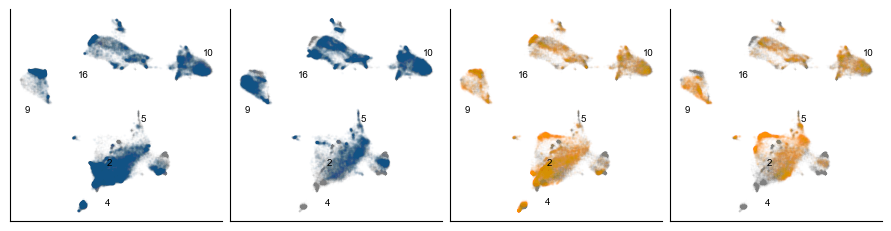

In [24]:
# Make UMAP plot which detail cell abundance at C1 and C7 (include patients which a C7D22 and missing a C7D1) 
plt.rcParams["font.family"] = "Arial"
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 'truetype'
plt.rcParams.update({'mathtext.default': 'regular'})

color_dict = {'non-responder_2': '#fe9003', 'responder_1': '#115284', 'Healthy': 'grey'}

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(8.8, 2.2), constrained_layout=True)

# Define plot configurations
plot_configs = [
    ('responder_1', 'C1_D1'),
    ('responder_1', 'C7_D1'),
    ('non-responder_2', 'C1_D1'),
    ('non-responder_2', 'C7_D1')
]

# Plot each panel
for ax, (response, timepoint) in zip(axes, plot_configs):
    healthy = cells1[cells1['best_response'] == 'Control']
    ax.scatter(healthy['UMAP_X'], healthy['UMAP_Y'], 
               color='grey', s=1, linewidth=0, alpha=0.02, rasterized=True)
    
    if timepoint == 'C7_D1':
        mask = (
            (cells1['best_response'] == response) & 
            (
                (cells1['Timepoint'] == 'C7_D1') |
                ((cells1['Timepoint'] == 'C7_D22') & (cells1['PID_Timepoint'].isin(patient_tp)))
            )
        )
    else:
        mask = (cells1['best_response'] == response) & (cells1['Timepoint'] == timepoint)

    subset = cells1[mask]
    ax.scatter(subset['UMAP_X'], subset['UMAP_Y'],
               c=subset['best_response'].map(color_dict),
               s=1, alpha=0.025, rasterized=True)

# Apply styling to all axes
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.set(xlabel='', ylabel='', xticks=[], yticks=[])
    
    for label, value in responder_text_dict.items():
        ax.text(x=value['xpos'], y=value['ypos'], s=str(label), fontsize=7)

#fig.savefig('../result/layout_version_7_2.pdf', bbox_inches='tight', pad_inches=0.01, dpi=1200)